E-Commerce Customer Analysis EDA Project
📌 Project Introduction:

1.Analyze customer purchasing behavior to uncover meaningful business insights from e-commerce data.

2.Explore customer demographics, shopping habits, and transaction patterns using Exploratory Data Analysis (EDA).

3.Identify key factors influencing customer engagement, spending, and loyalty.

4.Visualize hidden trends to support data-driven business decision-making.

5.Transform raw customer data into actionable insights for improving business performance.

📌 Problem Statement:

1.Understand the purchasing behavior of different customer segments.

2.Identify the factors affecting customer spending and engagement.

3.Discover patterns in customer demographics and buying habits.

4.Analyze customer lifetime value and overall business performance.

5.Provide insights to help businesses improve customer retention and revenue.

📌 Project Objectives:

1.Perform data cleaning and preprocessing for accurate analysis.

2.Explore customer demographic and behavioral patterns.

3.Analyze purchase frequency, order value, and spending trends.

4.Identify the most valuable customer segments.

5.Examine the relationship between customer attributes and purchasing behavior.

6.Detect outliers, anomalies, and hidden patterns in the dataset.

7.Create insightful visualizations for better business understanding.

8.Generate actionable business recommendations based on data insights.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving ecommerce_customer_churn_dataset.csv to ecommerce_customer_churn_dataset.csv


In [ ]:
df=pd.read_csv("ecommerce_customer_churn_dataset.csv")
df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


In [ ]:
df.shape

(50000, 25)

In [ ]:
df.columns

Index(['Age', 'Gender', 'Country', 'City', 'Membership_Years',
       'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session',
       'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases',
       'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
       'Customer_Service_Calls', 'Product_Reviews_Written',
       'Social_Media_Engagement_Score', 'Mobile_App_Usage',
       'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance',
       'Churned', 'Signup_Quarter'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null 

In [ ]:
df.describe()

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,...,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned
count,47505.000000,50000.000000,50000.000000,46601.000000,47000.000000,50000.000000,46000.000000,50000.000000,50000.000000,47000.000000,...,45509.000000,47472.000000,49832.000000,46500.000000,44000.000000,45000.000000,47500.000000,50000.000000,44500.000000,50000.000000
mean,37.802968,2.984009,11.624660,27.660754,8.737811,57.079973,4.298391,13.111576,123.117330,29.792872,...,6.680913,20.937980,5.681831,2.853312,29.364466,19.371607,2.353874,1440.626292,1966.233258,0.289000
std,11.834668,2.059105,7.810657,10.871013,3.778220,16.282723,3.189754,7.017312,175.569714,29.695062,...,6.143027,14.252561,2.676052,2.328948,20.574021,9.419252,1.110012,907.249443,1225.072166,0.453302
min,5.000000,0.100000,0.000000,1.000000,1.000000,0.000000,0.000000,-13.000000,26.380000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,29.000000,1.400000,6.000000,19.700000,6.000000,46.400000,2.000000,8.000000,87.050000,9.000000,...,2.900000,9.900000,4.000000,1.000000,13.200000,12.500000,2.000000,789.817500,1049.000000,0.000000
50%,38.000000,2.500000,11.000000,26.800000,8.400000,58.100000,4.000000,12.000000,112.970000,21.000000,...,5.400000,19.700000,5.000000,2.000000,27.600000,18.600000,2.000000,1243.415000,1896.000000,0.000000
75%,46.000000,4.000000,17.000000,34.700000,11.200000,68.700000,6.000000,17.000000,144.440000,41.000000,...,9.100000,30.400000,7.000000,4.000000,43.100000,25.500000,3.000000,1874.000000,2791.000000,1.000000
max,200.000000,10.000000,46.000000,75.600000,24.100000,143.743350,28.000000,128.700000,9666.379178,287.000000,...,99.615734,91.700000,21.000000,21.000000,100.000000,61.900000,5.000000,8987.240000,7197.000000,1.000000


In [ ]:
df.isnull().sum()

,0
Age,2495
Gender,0
Country,0
City,0
Membership_Years,0
Login_Frequency,0
Session_Duration_Avg,3399
Pages_Per_Session,3000
Cart_Abandonment_Rate,0
Wishlist_Items,4000


In [ ]:
num_cols = [
    'Age',
    'Session_Duration_Avg',
    'Pages_Per_Session',
    'Wishlist_Items',
    'Days_Since_Last_Purchase',
    'Discount_Usage_Rate',
    'Returns_Rate',
    'Email_Open_Rate',
    'Customer_Service_Calls',
    'Product_Reviews_Written',
    'Social_Media_Engagement_Score',
    'Mobile_App_Usage',
    'Payment_Method_Diversity',
    'Credit_Balance'
]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Country,0
City,0
Membership_Years,0
Login_Frequency,0
Session_Duration_Avg,0
Pages_Per_Session,0
Cart_Abandonment_Rate,0
Wishlist_Items,0


In [ ]:
df.duplicated().sum()

np.int64(0)

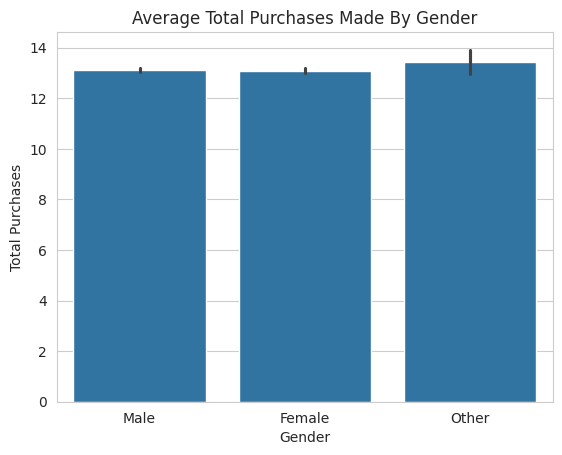

In [ ]:
# 📌 Problem 1:
#Understand the purchasing behavior of different customer segments.
#Q1:Which gender makes more purchases?
sns.barplot(data=df,x='Gender',y='Total_Purchases')
plt.title("Average Total Purchases Made By Gender")
plt.xlabel("Gender")
plt.ylabel("Total Purchases")
plt.show()


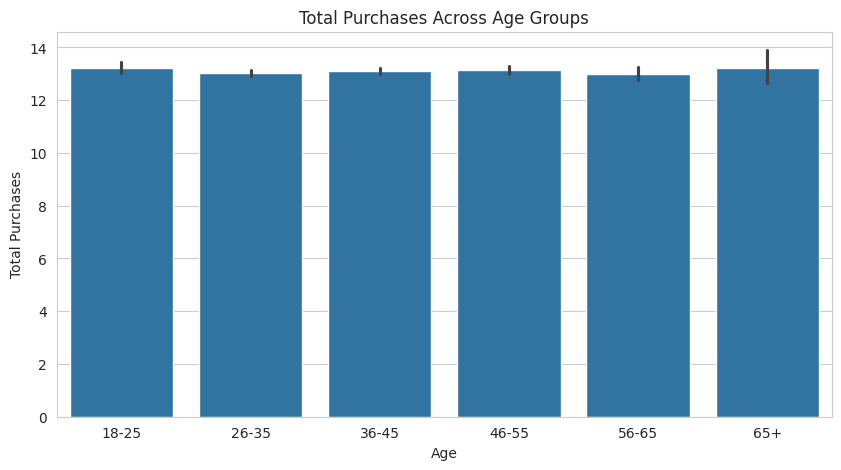

In [ ]:
#Q2:Which age group has the highest total purchases?
plt.figure(figsize=(10,5))
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)
sns.barplot(data=df,x='Age_Group',y='Total_Purchases')
plt.title("Total Purchases Across Age Groups")
plt.xlabel("Age")
plt.ylabel("Total Purchases")
plt.show()

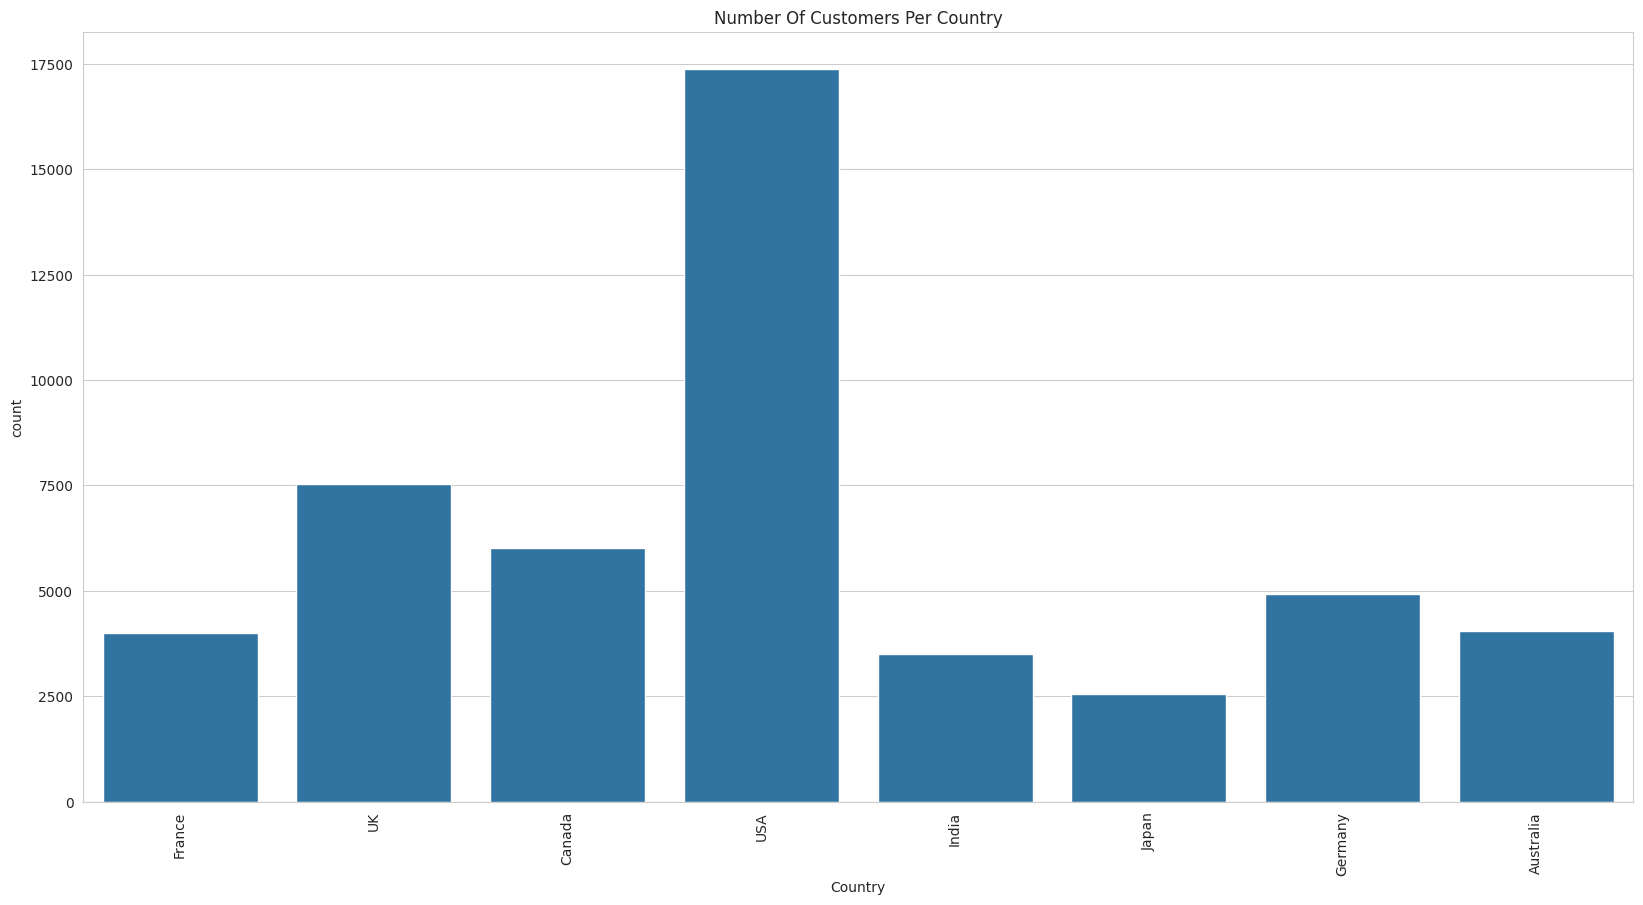

In [ ]:
#Q3:Which country has the highest number of customers?
plt.figure(figsize=(20,10))
sns.countplot(data=df,x="Country")
plt.title("Number Of Customers Per Country")
plt.xticks(rotation=90)
plt.show()

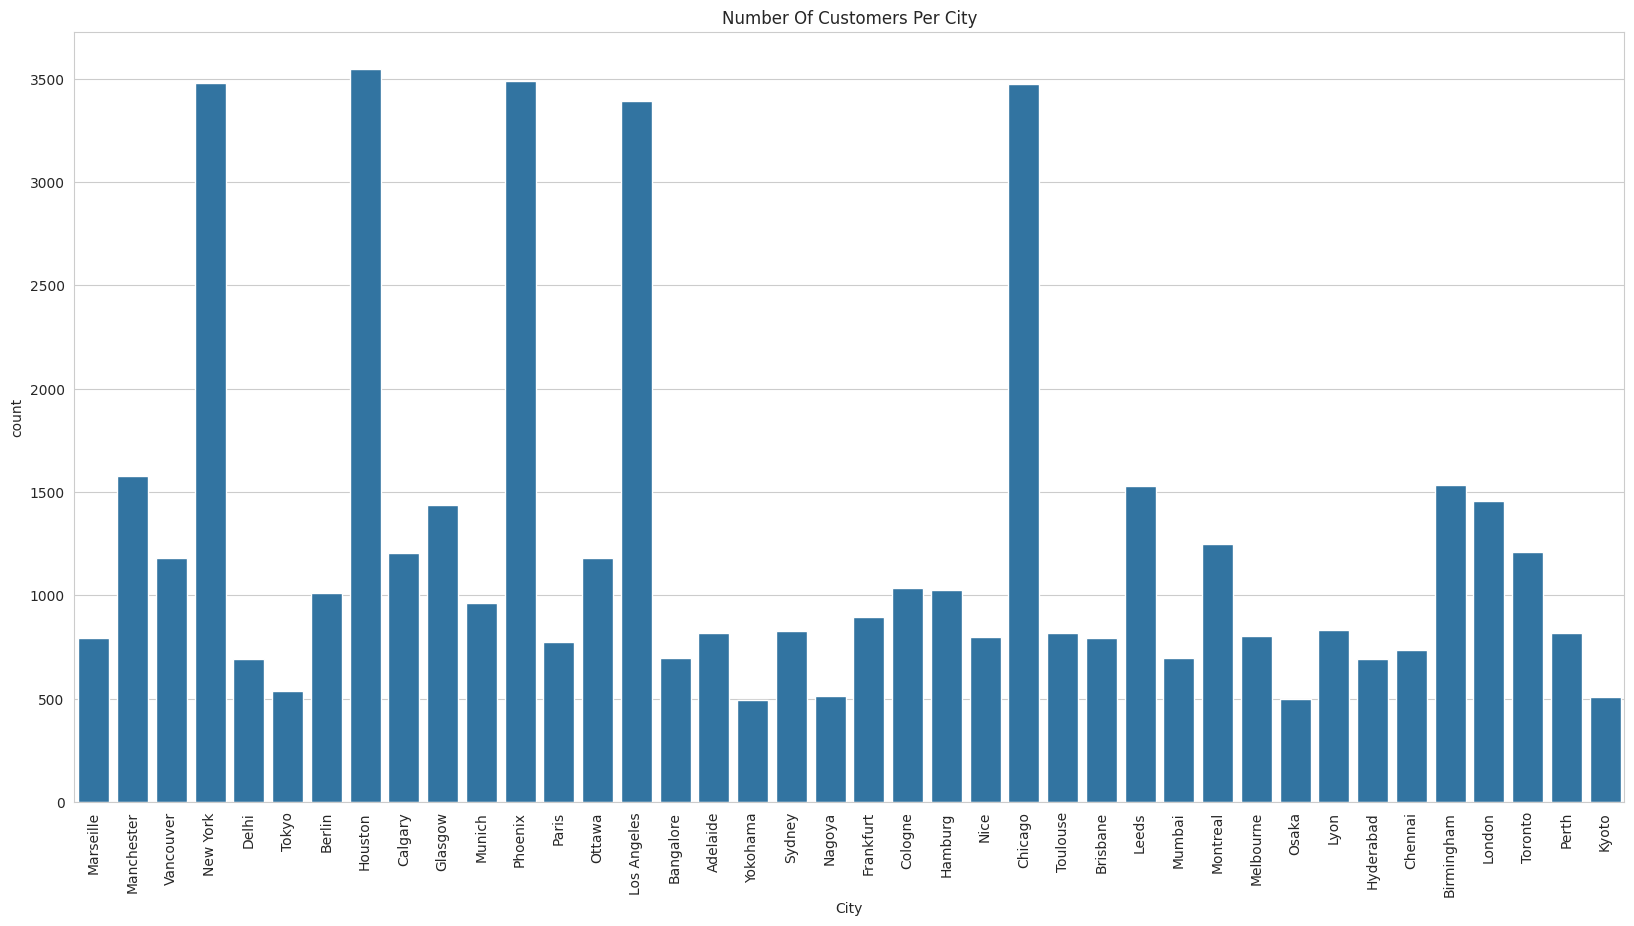

In [ ]:
#Q4:Which city has the highest number of customers?
plt.figure(figsize=(20,10))
sns.countplot(data=df,x="City")
plt.title("Number Of Customers Per City")
plt.xticks(rotation=90)
plt.show()

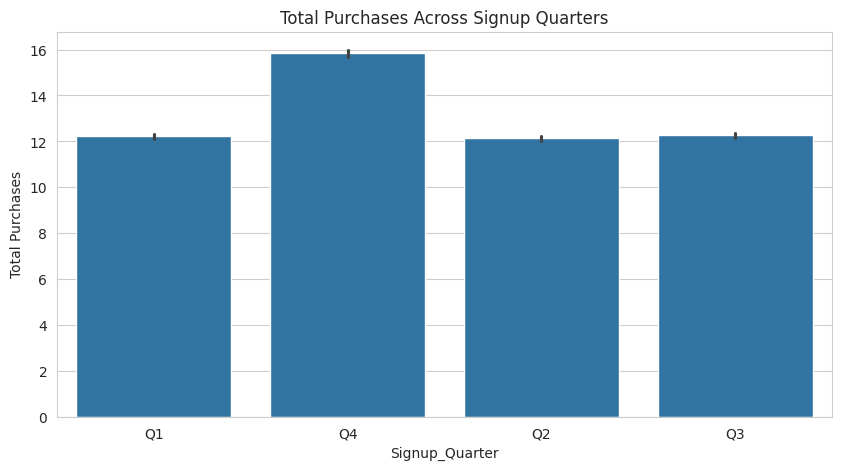

In [ ]:
#Q5:Which signup quarter has the highest total purchases?
plt.figure(figsize=(10,5))
sns.barplot(data=df,x='Signup_Quarter',y='Total_Purchases')
plt.title("Total Purchases Across Signup Quarters")
plt.xlabel("Signup_Quarter")
plt.ylabel("Total Purchases")
plt.show()

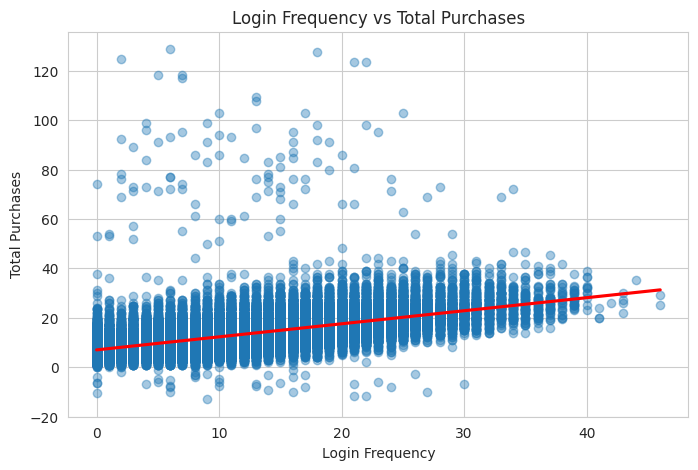

In [ ]:
#📌 Problem 2:
#Identify the factors affecting customer spending and engagement.
#Q6:Does login frequency affect total purchases?
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x='Login_Frequency',
    y='Total_Purchases',
    scatter_kws={'alpha':0.4},
    line_kws={'color':'red'}
)

plt.title("Login Frequency vs Total Purchases")
plt.xlabel("Login Frequency")
plt.ylabel("Total Purchases")

plt.show()

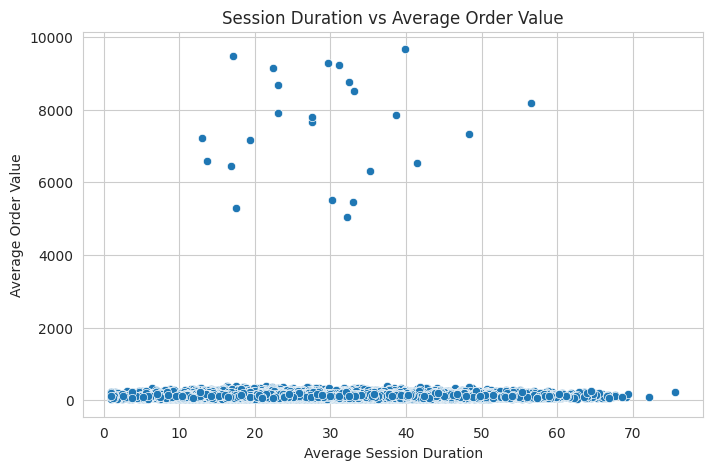

In [ ]:
#Q7:Does session duration influence average order value?
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Session_Duration_Avg',
    y='Average_Order_Value',
)

plt.title("Session Duration vs Average Order Value")
plt.xlabel("Average Session Duration")
plt.ylabel("Average Order Value")

plt.show()

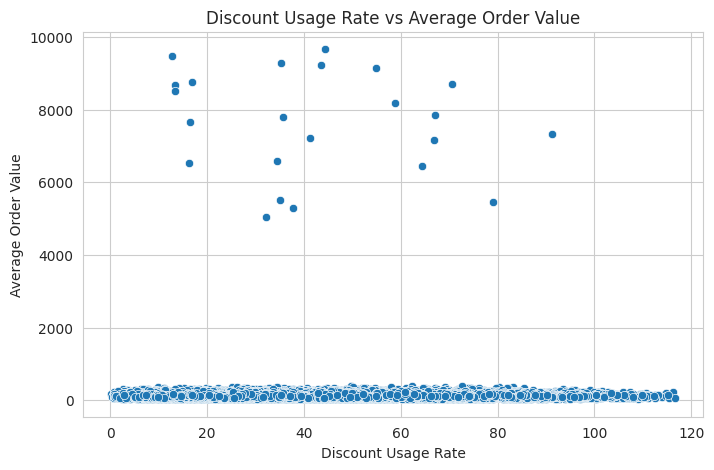

In [ ]:
#Q8:Does discount usage affect customer spending?
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Discount_Usage_Rate',
    y='Average_Order_Value'
)

plt.title("Discount Usage Rate vs Average Order Value")
plt.xlabel("Discount Usage Rate")
plt.ylabel("Average Order Value")

plt.show()

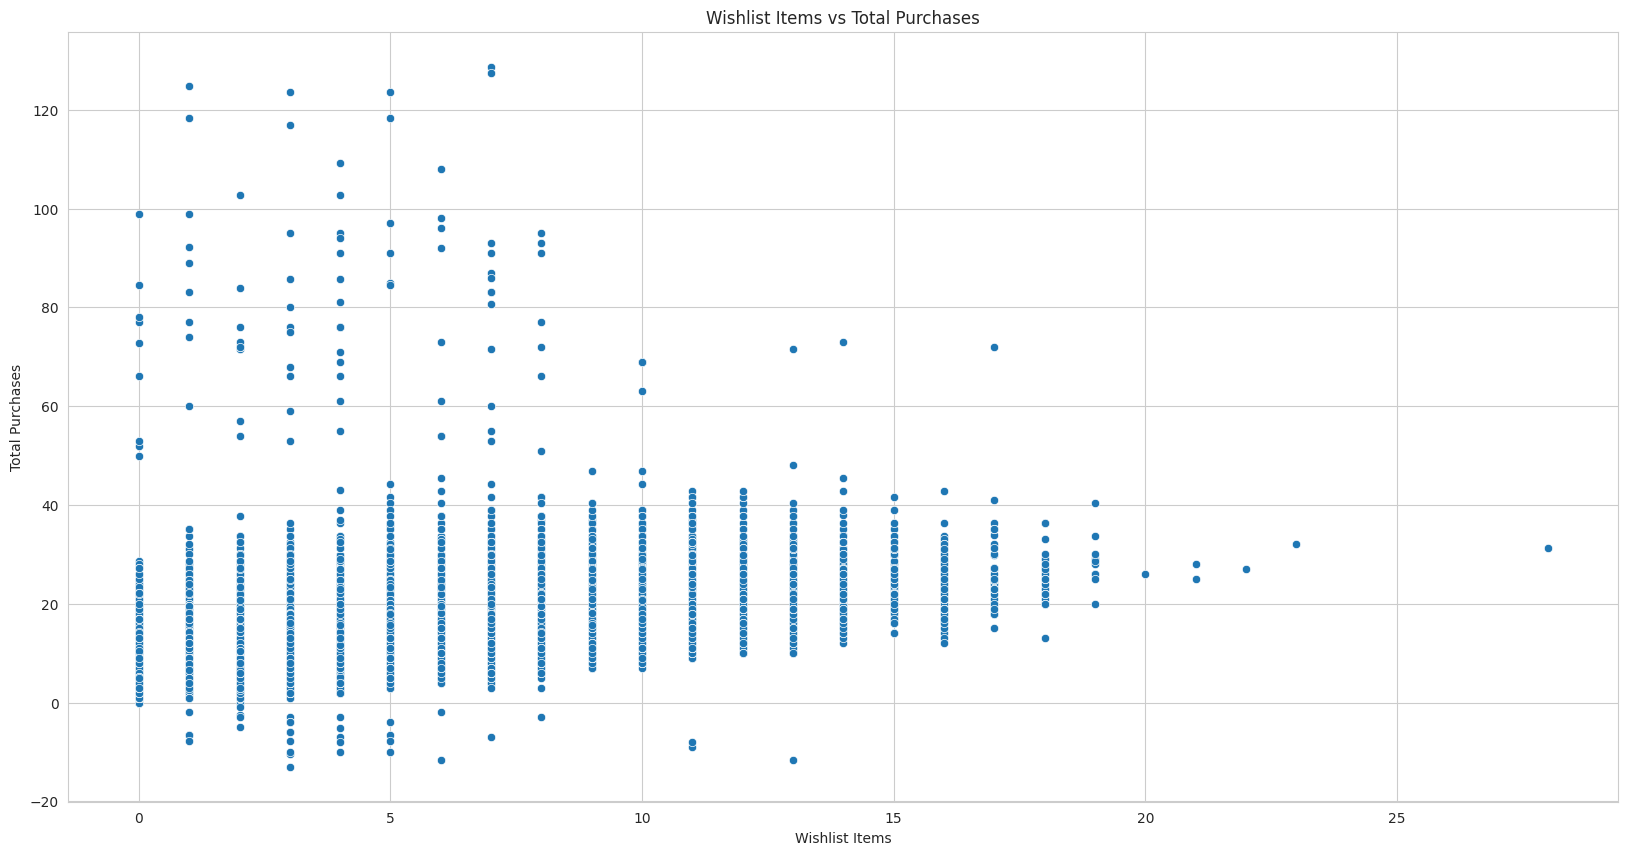

In [ ]:
#Q9:Does wishlist size influence purchasing behavior?
plt.figure(figsize=(20,10))
sns.scatterplot(data=df,x='Wishlist_Items',y='Total_Purchases')
plt.title("Wishlist Items vs Total Purchases")
plt.xlabel("Wishlist Items")
plt.ylabel("Total Purchases")
plt.show()

In [ ]:
import plotly.express as px
#Q10: Does mobile app usage improve customer engagement?
fig=px.scatter(df,x='Mobile_App_Usage',y='Login_Frequency',color='Gender',title='Mobile App Usage vs Login Frequency')
fig.show()

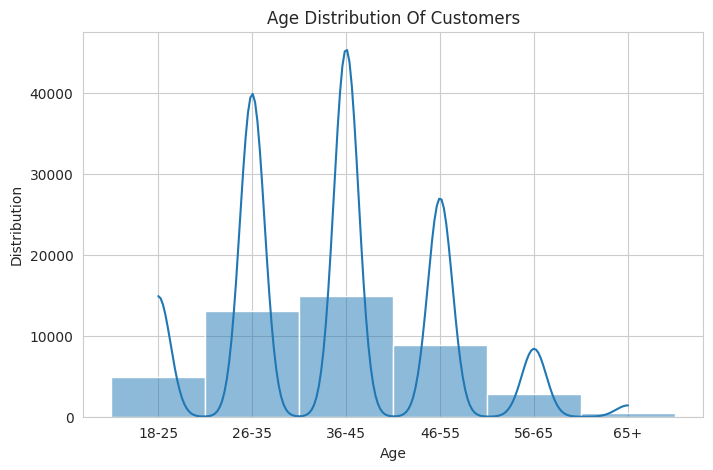

In [ ]:
#📌 Problem 3:
#Discover patterns in customer demographics and buying habits.
#Q11:What is the age distribution of customers?
plt.figure(figsize=(8,5))
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)
sns.histplot(data=df,x='Age_Group',bins=20,kde=True)
plt.title("Age Distribution Of Customers")
plt.xlabel("Age")
plt.ylabel("Distribution")
plt.show()

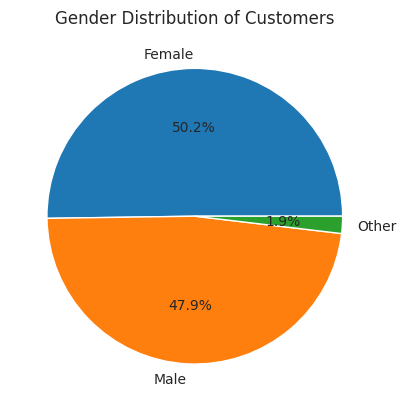

In [ ]:
#Q12:What is the gender distribution of customers?
gender_counts = df['Gender'].value_counts()

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%'
)
plt.title("Gender Distribution of Customers")
plt.show()

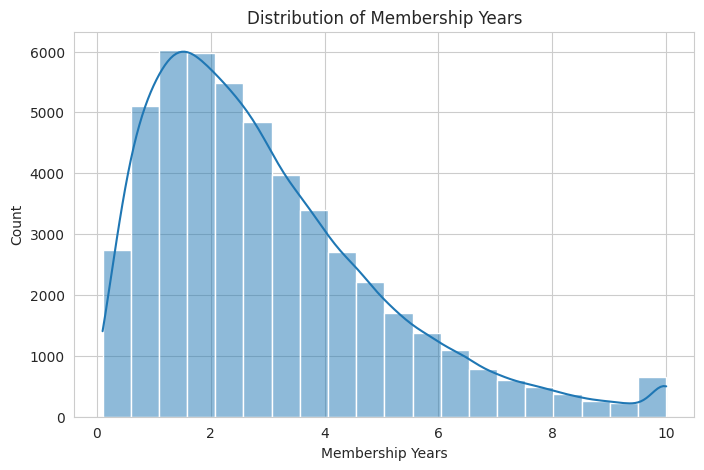

In [ ]:
#Q13:What is the distribution of membership years?
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Membership_Years',
    kde=True,
    bins=20
)

plt.title("Distribution of Membership Years")
plt.xlabel("Membership Years")
plt.ylabel("Count")

plt.show()

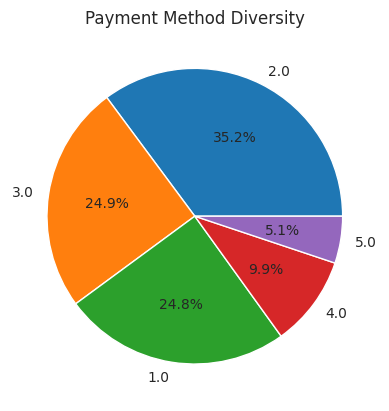

In [ ]:
#Q14: Which payment method diversity is most common?
payment_method_counts=df['Payment_Method_Diversity'].value_counts()
plt.pie(payment_method_counts,labels=payment_method_counts.index,autopct='%1.1f%%')
plt.title("Payment Method Diversity")
plt.show()


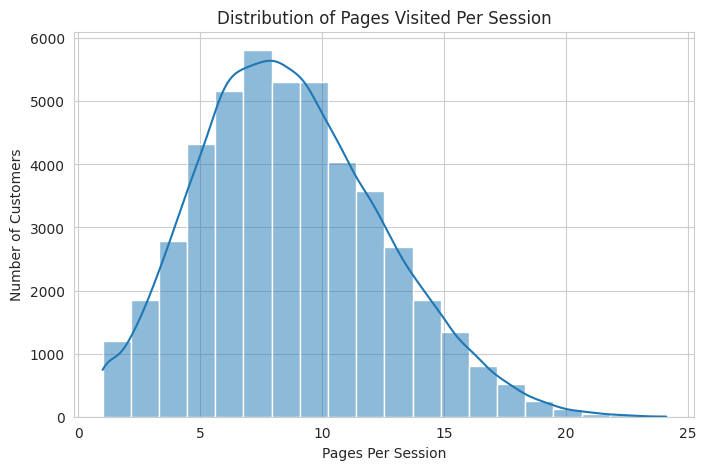

In [ ]:
# Q15: How many pages do customers visit in a session?
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Pages_Per_Session',
    kde=True,
    bins=20
)

plt.title("Distribution of Pages Visited Per Session")
plt.xlabel("Pages Per Session")
plt.ylabel("Number of Customers")

plt.show()

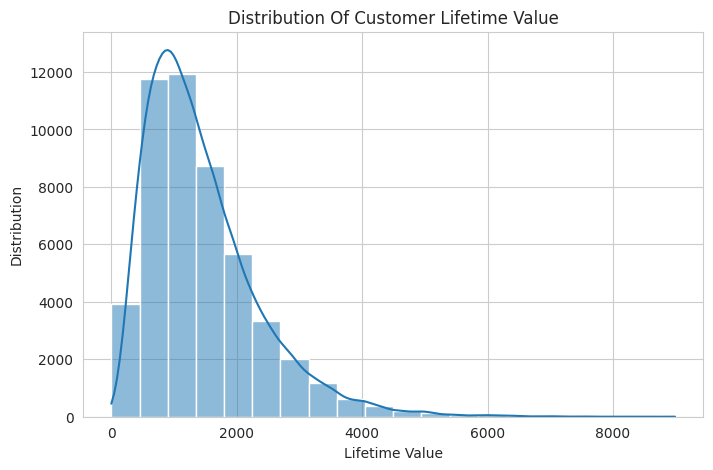

In [ ]:
#📌 Problem 4:
#Analyze customer lifetime value and overall business performance.
#Q16:What is the distribution of customer lifetime value?
plt.figure(figsize=(8,5))
sns.histplot(data=df,x="Lifetime_Value",bins=20,kde=True)
plt.title("Distribution Of Customer Lifetime Value")
plt.xlabel("Lifetime Value")
plt.ylabel("Distribution")
plt.show()


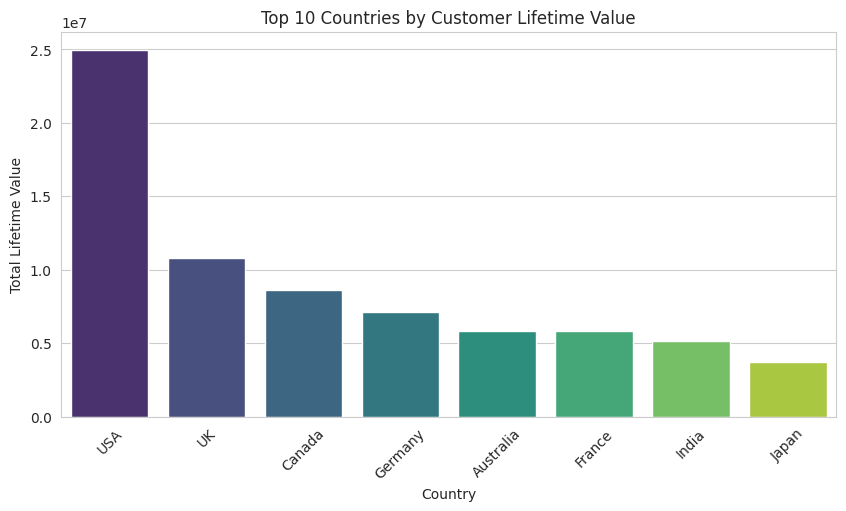

In [ ]:
#Q17:Which country has the highest customer lifetime value?
# Top 10 Countries by Total Lifetime Value

top10_country = (
    df.groupby('Country')['Lifetime_Value']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top10_country,
    x='Country',
    y='Lifetime_Value',
    hue='Country',
    palette='viridis',
    legend=False
)

plt.title("Top 10 Countries by Customer Lifetime Value")
plt.xlabel("Country")
plt.ylabel("Total Lifetime Value")
plt.xticks(rotation=45)

plt.show()

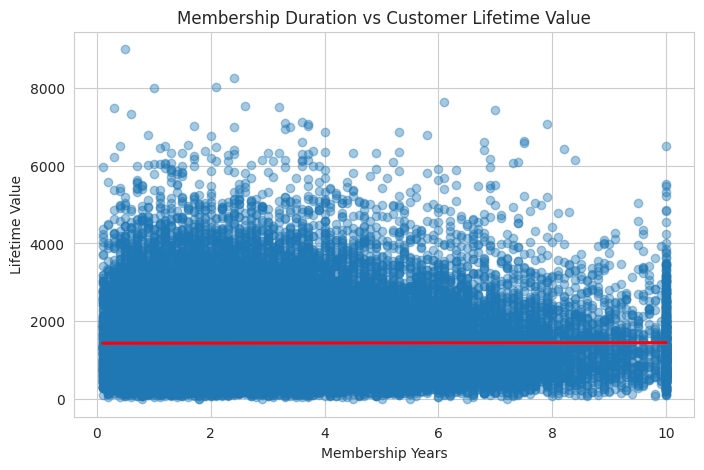

In [ ]:
#Q18:Does membership duration increase lifetime value?
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x='Membership_Years',
    y='Lifetime_Value',
    scatter_kws={'alpha':0.4},
    line_kws={'color':'red'}
)

plt.title("Membership Duration vs Customer Lifetime Value")
plt.xlabel("Membership Years")
plt.ylabel("Lifetime Value")

plt.show()

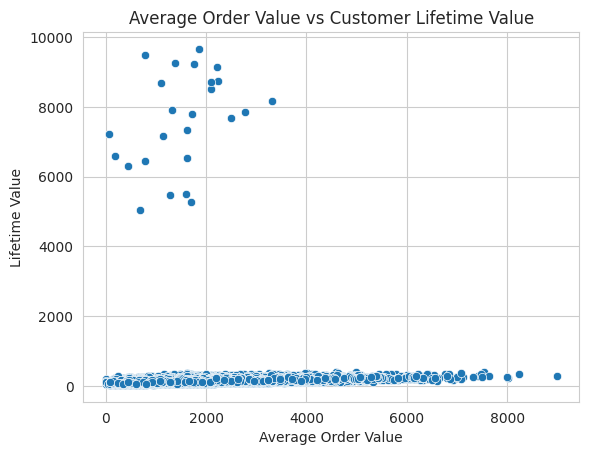

In [ ]:
#Q19:Does average order value affect lifetime value?
sns.scatterplot(data=df,x='Lifetime_Value',y='Average_Order_Value')
plt.title("Average Order Value vs Customer Lifetime Value")
plt.xlabel("Average Order Value")
plt.ylabel("Lifetime Value")
plt.show()

In [ ]:
#Q20:Which countries contribute the highest lifetime value?
import plotly.express as px

country_ltv = (
    df.groupby('Country', as_index=False)['Lifetime_Value']
      .sum()
)

fig = px.treemap(
    country_ltv,
    path=['Country'],
    values='Lifetime_Value',
    color='Lifetime_Value',
    title='Customer Lifetime Value by Country'
)

fig.show()

Churned
0    35550
1    14450
Name: count, dtype: int64


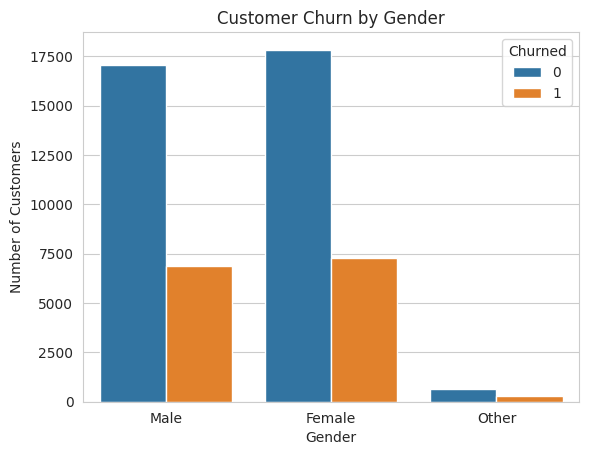

In [ ]:
#📌 Problem 5:
#Provide insights to help businesses improve customer retention and revenue.
#Q21:Which customers are more likely to churn?
churn_counts=df['Churned'].value_counts()
print(churn_counts)
sns.countplot(data=df, x='Gender', hue='Churned')
plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

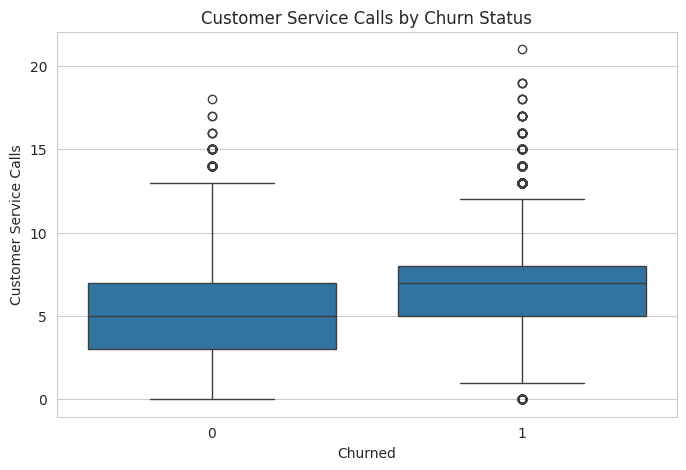

In [ ]:
#Q22:Does customer service interaction relate to churn?
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Churned',
    y='Customer_Service_Calls'
)

plt.title("Customer Service Calls by Churn Status")
plt.xlabel("Churned")
plt.ylabel("Customer Service Calls")

plt.show()

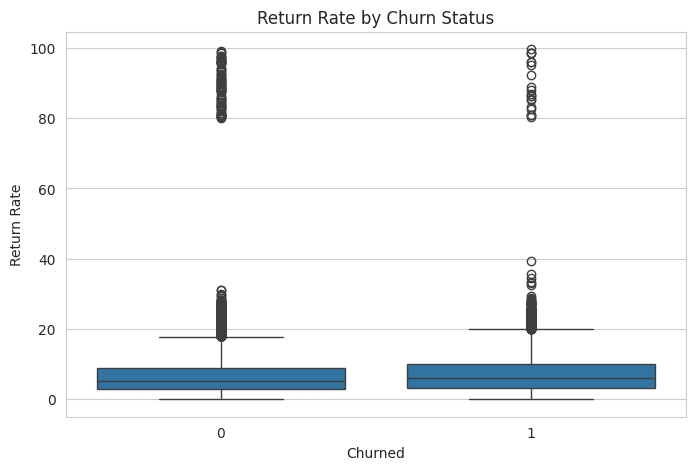

In [ ]:
#Q23:Does return rate affect churn?
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Churned',
    y='Returns_Rate'
)

plt.title("Return Rate by Churn Status")
plt.xlabel("Churned")
plt.ylabel("Return Rate")

plt.show()

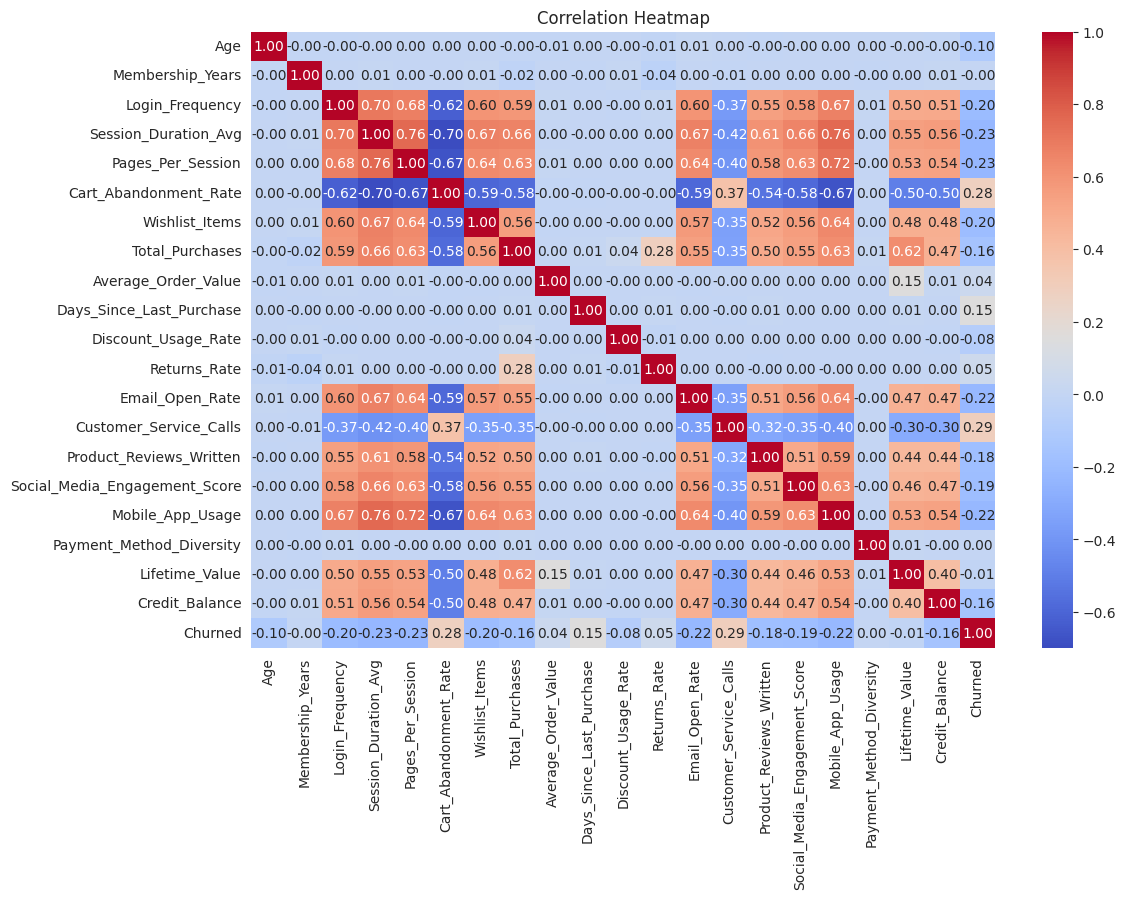

In [ ]:
#Which variables are highly correlated with churn?
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

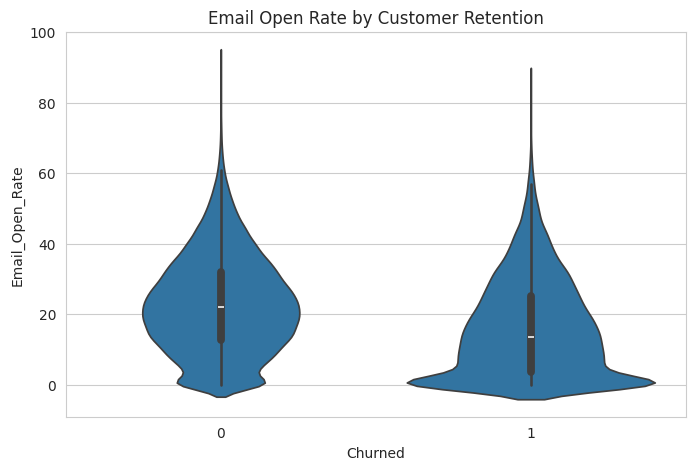

In [ ]:
#Q24:Does email open rate impact customer retention?
plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x='Churned',
    y='Email_Open_Rate'
)

plt.title("Email Open Rate by Customer Retention")

plt.show()

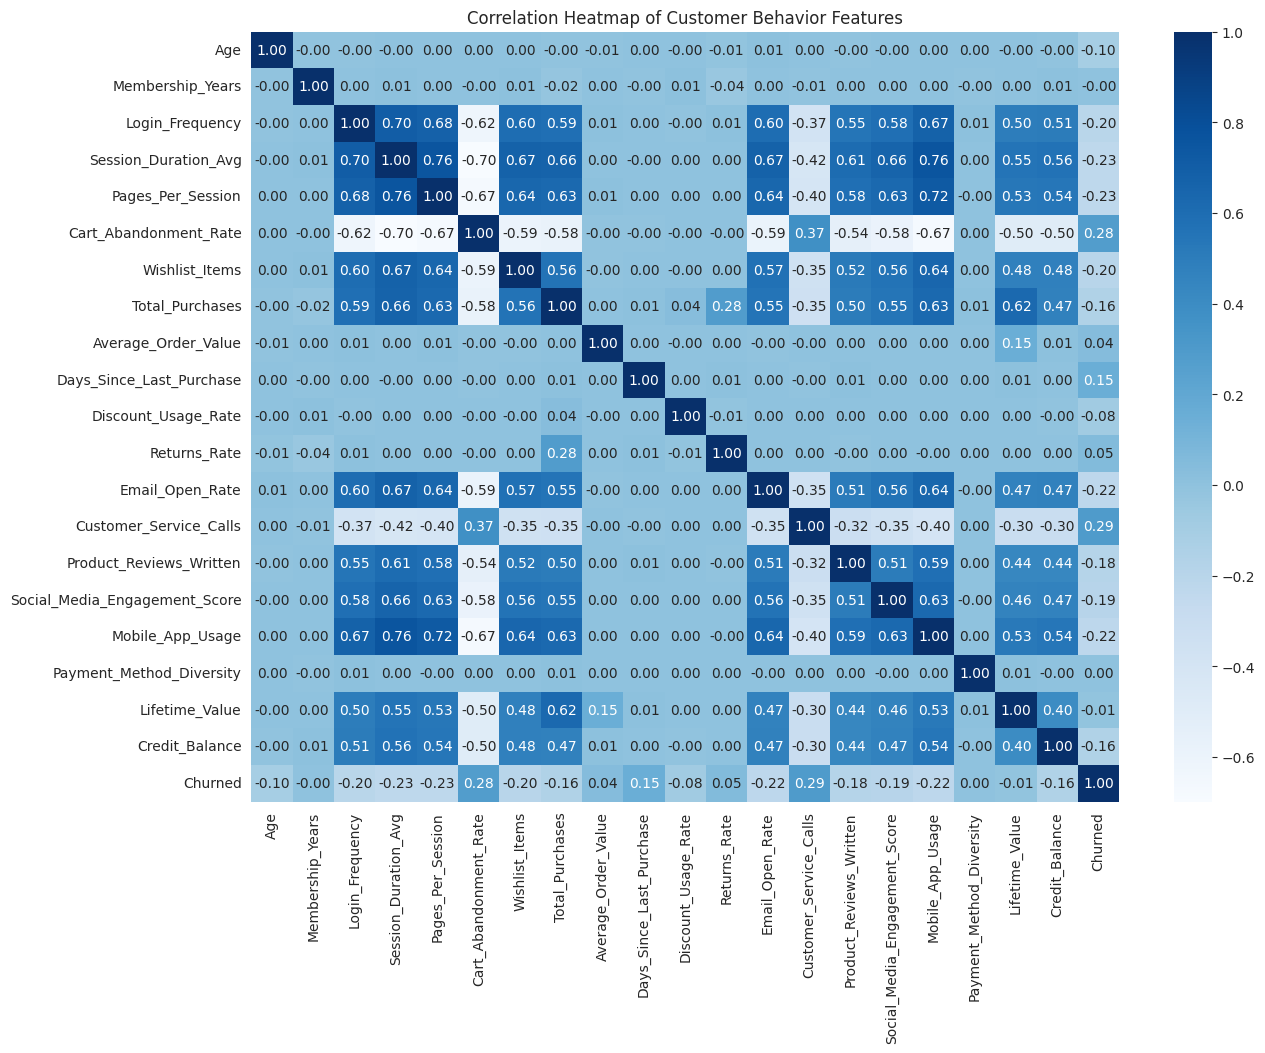

In [ ]:
#Q25:Which factors are most strongly correlated with churn?
plt.figure(figsize=(14,10))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='Blues',
    fmt='.2f'
)

plt.title("Correlation Heatmap of Customer Behavior Features")

plt.show()

# Conclusion

* The analysis showed that customer behavior is influenced by multiple factors such as login frequency, session duration, discount usage, membership years, and mobile app usage.
* Customers with higher engagement generally tend to make more purchases and contribute greater lifetime value.
* Membership duration and average order value have a positive relationship with customer lifetime value, highlighting the importance of long-term customer retention.
* Customer lifetime value varies across countries, indicating that some markets contribute significantly more to overall business revenue.
* Churn analysis revealed that factors such as return rate, customer service interactions, and email engagement can influence customer retention.
* Correlation analysis helped identify the variables most strongly associated with customer churn and overall customer value.
* The visualizations provided meaningful insights into customer demographics, purchasing patterns, engagement behavior, and retention trends.
* These findings can help e-commerce businesses optimize marketing strategies, improve customer experience, reduce churn, and focus on high-value customer segments to maximize long-term profitability.


OVERALL FINAL BUSINESS INSIGHTS :
The analysis shows that customer engagement, purchase behavior, membership duration, mobile app usage, and average order value play a significant role in improving customer lifetime value, while factors such as high return rates, frequent customer service interactions, and low engagement contribute to customer churn. These insights can help businesses improve customer retention, increase sales, and make data-driven marketing decisions.

# Business Recommendations

* Focus marketing campaigns on the highest-performing age groups and customer segments to maximize sales and return on investment.
* Increase investment in the top-performing countries and cities to strengthen market presence and business growth.
* Launch targeted campaigns during the highest-performing signup quarter to acquire more valuable customers.
* Encourage frequent customer logins through personalized notifications, rewards, and loyalty programs to increase purchases.
* Improve website and mobile app experience to increase session duration and customer engagement.
* Offer personalized discounts to customers based on their purchase history to boost conversion rates without reducing profitability.
* Continue enhancing the mobile app with exclusive offers and features to improve customer engagement and retention.
* Implement strategies to convert wishlist items into completed purchases through reminders and personalized recommendations.
* Reduce cart abandonment by simplifying the checkout process and sending abandoned cart recovery emails.
* Prioritize customer retention programs, as long-term members generate higher customer lifetime value.
* Focus on increasing average order value through product bundles, cross-selling, and upselling strategies.
* Strengthen customer support by resolving issues quickly to reduce customer churn and improve satisfaction.
* Monitor product quality and minimize return rates to improve customer trust and reduce churn risk.
* Improve email marketing campaigns with personalized content to increase email open rates and customer retention.
* Encourage customers to leave product reviews by offering incentives, as highly engaged customers often generate greater business value.
* Expand payment options and provide seamless payment experiences to improve customer convenience and long-term value.
* Leverage social media campaigns and customer engagement activities to strengthen brand loyalty and increase purchasing behavior.
* Regularly monitor key customer behavior metrics using dashboards to identify changing trends and support data-driven decision-making.
* Build predictive customer segmentation strategies to identify high-value customers and proactively reduce churn.
* Continuously analyze customer behavior using EDA to optimize marketing strategies, improve customer experience, and maximize long-term profitability.


In [1]:
pip freeze > requirements.txt